In [ ]:
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import Dataset, DataLoader, ConcatDataset, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from scipy.stats import qmc

from IPython.display import clear_output
import time
from datetime import datetime, timedelta
import gc

np.random.seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [ ]:
# Neural Network
class PINN_Module(nn.Module):

    def __init__(self, model_parameters):
        super(PINN_Module, self).__init__()
        self.Device = model_parameters["Device"]
        self.LowerBounds = model_parameters["LowerBounds"]
        self.UpperBounds = model_parameters["UpperBounds"]
        self.Density = model_parameters["Density"]
        self.SpecificHeatCapacity = model_parameters["SpecificHeatCapacity"]
        self.InputDimensions = model_parameters["InputDimensions"]
        self.OutputDimensions = model_parameters["OutputDimensions"]
        self.NumberOfNeurons = model_parameters["NumberOfNeurons"]
        self.NumberOfHiddenLayers = model_parameters["NumberOfHiddenLayers"]
        self.ActivationFunction = model_parameters["ActivationFunction"]
        self.InputLayer = nn.Linear(self.InputDimensions, self.NumberOfNeurons)
        self.HiddenLayers = nn.ModuleList(
            [nn.Linear(self.NumberOfNeurons, self.NumberOfNeurons) for _ in range(self.NumberOfHiddenLayers - 1)])
        self.OutputLayer = nn.Linear(self.NumberOfNeurons, self.OutputDimensions)

        self.init_xavier()


    def forward(self, x):
        lb = self.LowerBounds
        ub = self.UpperBounds
        x = 2*(x - lb)/(ub - lb) - 1
        output = self.ActivationFunction(self.InputLayer(x))
        for k, l in enumerate(self.HiddenLayers):
            output = self.ActivationFunction(l(output))
        output = self.OutputLayer(output)
        return output


    def init_xavier(self):

        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                g = nn.init.calculate_gain('tanh')
                torch.nn.init.xavier_uniform_(m.weight, gain=g)
                # torch.nn.init.xavier_normal_(m.weight, gain=g)
                m.bias.data.fill_(0)

        self.apply(init_weights)


    def internalEnergyBalanceResidue(self, X):

        x = X[:, 0:1].clone().detach().requires_grad_(True)
        t = X[:, 1:2].clone().detach().requires_grad_(True)
        k = X[:, 2:3]  # no grad needed

        X_clean = torch.cat([x, t, k], dim=1)
        T = self.forward(X_clean)

        rho = self.Density
        cp = self.SpecificHeatCapacity

        Tt = torch.autograd.grad(T, t, grad_outputs=torch.ones_like(T), create_graph=True)[0]
        Tx = torch.autograd.grad(T, x, grad_outputs=torch.ones_like(T), create_graph=True)[0]
        Txx = torch.autograd.grad(Tx, x, grad_outputs=torch.ones_like(Tx), create_graph=True)[0]

        alpha = k/(rho*cp)
        residue = Tt - alpha*Txx
        return residue


## Problem data

In [ ]:
# Properties of pure solid aluminium
k = 210.0 # W/(m K)
C = 900.0 # J/(kg K)
rho = 2700.0 #kg/m^3
alpha_Al = k/(rho*C)

# Boundaries of space and time domains
ti, tf = 0.0, 1000.0 # s
xi, xf = 0.0, 1.0 # m

# Boundaries for the variation of the thermal conductivity
ki, kf = 200.0, 300.0

lb = torch.tensor([xi, ti, ki])
ub = torch.tensor([xf, tf, kf])

# Initial and boundary temperatures
bc_value = bc_value_l = bc_value_r = 300.0 # K
k1 = np.pi/xf
T_ampl = 100.0 # K
T0 = lambda x: T_ampl*torch.sin(k1*x) + bc_value # K

## Exact solution

In [ ]:
# Exact solution
T_exact = lambda x, t, k: T_ampl*np.sin(k1*x)*np.exp(-k1**2*(k/(rho*C))*t) + bc_value

# Grid for evaluation the exact solution
x_test = np.linspace(xi, xf, 1000)
t_test = np.linspace(ti, tf, 1000)
ms_x, ms_t = np.meshgrid(x_test, t_test)
x_test = np.ravel(ms_x).reshape(-1,1)
t_test = np.ravel(ms_t).reshape(-1,1)
k_test = np.full_like(x_test, k)

T_ex_grid = T_exact(x_test, t_test, k_test).reshape(ms_x.shape)

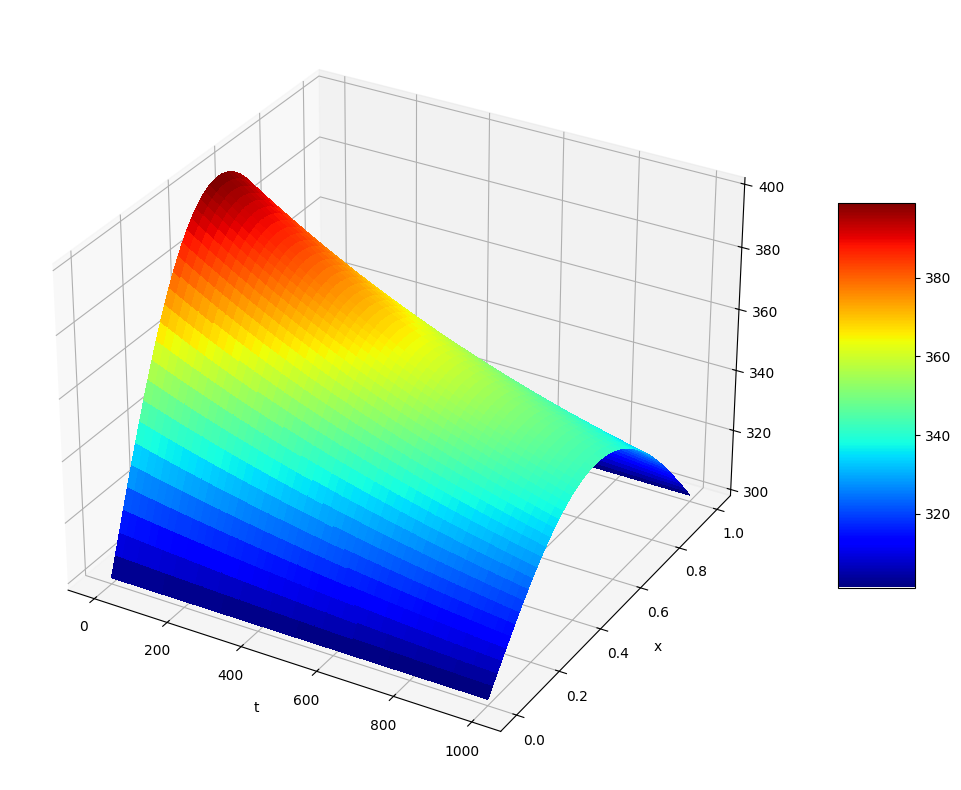

In [ ]:
# Plot the exact temperature distribution
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
#ax.view_init(elev=20, azim=-90)
surf1 = ax.plot_surface(ms_t, ms_x, T_ex_grid, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf1, shrink=0.5, aspect=5)
plt.xlabel('t')
plt.ylabel('x')
plt.show()

## Datasets (collocation points and labelled data points)

In [ ]:
# Generate equispaced tensors for both space and time domains to pick from
x_tensor = torch.linspace(xi, xf, 10000, device=device)
t_tensor = torch.linspace(ti, tf, 10000, device=device)
k_tensor = torch.linspace(ki, kf, 10000, device=device)

# Number of collocation points
N_dom = 10000 # Number of collocation points for evaluating the residuals
N_bc = 3000 # Number of collocation points for computing the boundary conditions
N_ic = 5000 # Number of collocation points for computing the initial condition
N_data = 2000 # Number of labelled data points

# Train, validation and testing sets
tags = ["Domain", "BoundaryConditions", "InitialCondition"]
isData = False # Flag to indicate whether the analysis would use labelled data or not

# Initialize list of dataset objects
ds = []

In [ ]:
## Collocation points for evaluating the residual of the governing PDE

# Generate collocation points within the domain using Latin Hypercube Sampling (LHS) strategy
# (scipy.stats.qmc en lugar de pyDOE, con seed explicita para reproducibilidad,
# consistente con el resto de los notebooks del curso)
sampler = qmc.LatinHypercube(d=3, seed=0)
sample_unit = sampler.random(N_dom)  # puntos en [0,1]^3

lb_np = lb.numpy()
ub_np = ub.numpy()
X_dom = torch.from_numpy(lb_np + (ub_np - lb_np)*sample_unit).to(torch.float32).to(device)
y_dom = torch.zeros((N_dom, 1), device=device)

ds.append(TensorDataset(X_dom, y_dom))


In [ ]:
X_dom

tensor([[6.8839e-01, 8.1416e+02, 2.3590e+02],
        [3.6516e-01, 9.3050e+02, 2.3734e+02],
        [3.9160e-01, 7.4615e-01, 2.7934e+02],
        ...,
        [3.6368e-01, 7.4302e+02, 2.0751e+02],
        [7.3685e-01, 7.0595e+02, 2.5832e+02],
        [4.5815e-02, 6.8170e+02, 2.6005e+02]], device='cuda:0')

In [ ]:
## Collocation points for evaluating the boundary and initial conditions

# Generate random collocation points for the left boundary
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
t_bc_l = t_tensor[idx_bc].view(-1, 1)
x_bc_l = xi*torch.ones((N_bc, 1), device=device)
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
k_bc_l = k_tensor[idx_bc].view(-1, 1)
X_bc_l = torch.cat([x_bc_l, t_bc_l, k_bc_l], axis=1)
y_bc_l = torch.full((N_bc, 1), bc_value_l)

# Generate random collocation points for the right boundary
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
t_bc_r = t_tensor[idx_bc].view(-1, 1)
x_bc_r = xf*torch.ones((N_bc, 1), device=device)
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
k_bc_r = k_tensor[idx_bc].view(-1, 1)
X_bc_r = torch.cat([x_bc_r, t_bc_r, k_bc_r], axis=1)
y_bc_r = torch.full((N_bc, 1), bc_value_r)

# Concatenate the collocation points of both boundaries
X_bc = torch.cat([X_bc_l, X_bc_r], axis=0)
y_bc = torch.cat([y_bc_l, y_bc_r], axis=0)
ds.append(TensorDataset(X_bc, y_bc))

# Generate collocation points for the initial condition
idx_ic = np.random.choice(x_tensor.size()[0], N_ic, replace=False)
x_ic = x_tensor[idx_ic].view(-1, 1)
t_ic = ti*torch.ones((N_ic, 1), device=device)
idx_ic = np.random.choice(x_tensor.size()[0], N_ic, replace=False)
k_ic = k_tensor[idx_ic].view(-1, 1)
X_ic = torch.cat([x_ic, t_ic, k_ic], axis=1)
y_ic = T0(x_ic)
ds.append(TensorDataset(X_ic, y_ic))

In [ ]:
# Generate syntetic temperature labelled data
if isData:
    tags.append("LabelledData")
    omega = 0.01
    sensor_loc = [0.25, 0.5, 0.9]
    x_data, t_data, k_data = [], [], []
    for loc in sensor_loc:
        idx_data = np.random.choice(x_tensor.size()[0], N_data, replace=False)
        x_data.append(torch.full((N_data, 1), loc, device=device))
        t_data.append(t_tensor[idx_data].view(-1, 1))
        k_data.append(k_tensor[idx_data].view(-1, 1))

    X_data = torch.cat([torch.cat(x_data, axis=0), torch.cat(t_data, axis=0), torch.cat(k_data, axis=0)], axis=1)
    exact_temp_data = T_exact(X_data[:, 0].data.cpu().numpy(), X_data[:, 1].data.cpu().numpy(), X_data[:, 2].data.cpu().numpy())
    noisy_temp_data = exact_temp_data.reshape(-1, 1) + omega*np.max(exact_temp_data)*np.random.normal(size=(len(sensor_loc)*N_data, 1))
    y_data = torch.from_numpy(noisy_temp_data).to(torch.float32).to(device)
    ds.append(TensorDataset(X_data, y_data))


In [ ]:
# Dictionary of dataset objects
datasets = dict(zip(tags, ds))

## Main execution

In [ ]:
class Sin(nn.Module):
    def __init__(self, ):
        super().__init__()

    def forward(self, x):
        return torch.sin(x)

In [ ]:
# Input dictionary for model instance
model_parameters = {
    "Device": device,
    "LowerBounds": lb.to(device),
    "UpperBounds": ub.to(device),
    "Density": rho,
    "SpecificHeatCapacity": C,
    "InputDimensions": 3,
    "OutputDimensions": 1,
    "NumberOfNeurons": 50,
    "NumberOfHiddenLayers": 5,
    "ActivationFunction": Sin()
}

In [ ]:
# Model construction
torch.manual_seed(10)
model = PINN_Module(model_parameters).to(device)

In [ ]:
# Fitting stage
t0 = datetime.now()
data_time_now = datetime.now().strftime("%d%m%Y_%H%M%S")

epochs = 5000
lr = 1e-3
loss_fn = nn.MSELoss()
optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=0.8,
    max_iter=1,
    max_eval=50000,
    line_search_fn="strong_wolfe",
    tolerance_change=1.0 * np.finfo(float).eps
)
loss_train = []
loss_train_dom = []
loss_train_bc = []
loss_train_ic = []
loss_train_data = []
train_keys = ['Overall', 'Domain', 'BC', 'IC', 'Data']

# Contenedor para capturar las perdidas calculadas dentro de closure() y
# reutilizarlas para el logging, evitando un segundo forward pass completo
# (redundante) en cada epoca. Con LBFGS, closure() puede llamarse varias
# veces por paso (line search); nos quedamos con los valores de la ultima
# llamada, que corresponden al iterado final de la epoca.
last_loss_values = {}

for epoch in range(epochs):

    def closure():
        optimizer.zero_grad()
        loss_list = []
        for tag in tags:
            X = (datasets[tag][:][0]).to(device)
            y = (datasets[tag][:][1]).to(device)
            if tag == 'Domain':
                y_hat = model.internalEnergyBalanceResidue(X)
                loss = loss_fn(y_hat, y)
                loss_list.append(loss)
            else:
                T = model(X)
                loss = loss_fn(T, y)
                loss_list.append(loss)

        loss = sum(loss_list)
        loss.backward()

        last_loss_values['Overall'] = loss.item()
        for tag_, l in zip(tags, loss_list):
            last_loss_values[tag_] = l.item()

        return loss

    optimizer.step(closure)

    loss_train.append(last_loss_values['Overall'])
    loss_train_dom.append(last_loss_values['Domain'])
    loss_train_bc.append(last_loss_values['BoundaryConditions'])
    loss_train_ic.append(last_loss_values['InitialCondition'])
    if isData:
        loss_train_data.append(last_loss_values['LabelledData'])

    if epoch % 100 == 0:
        log_dict = {
            'Overall': last_loss_values['Overall'],
            'Domain': last_loss_values['Domain'],
            'BC': last_loss_values['BoundaryConditions'],
            'IC': last_loss_values['InitialCondition'],
        }
        if isData:
            log_dict['Data'] = last_loss_values['LabelledData']
        aux = "".join(f"{key}: {value:.5e}, " for key, value in log_dict.items())
        optimizer_str = type(optimizer).__name__
        print(f"##TRAIN## {optimizer_str} - Epoch: {epoch}, " + aux)

elapsed_time_train = datetime.now() - t0
print("\nTraining Time: ", elapsed_time_train.seconds, "[s]")


## Loss functions

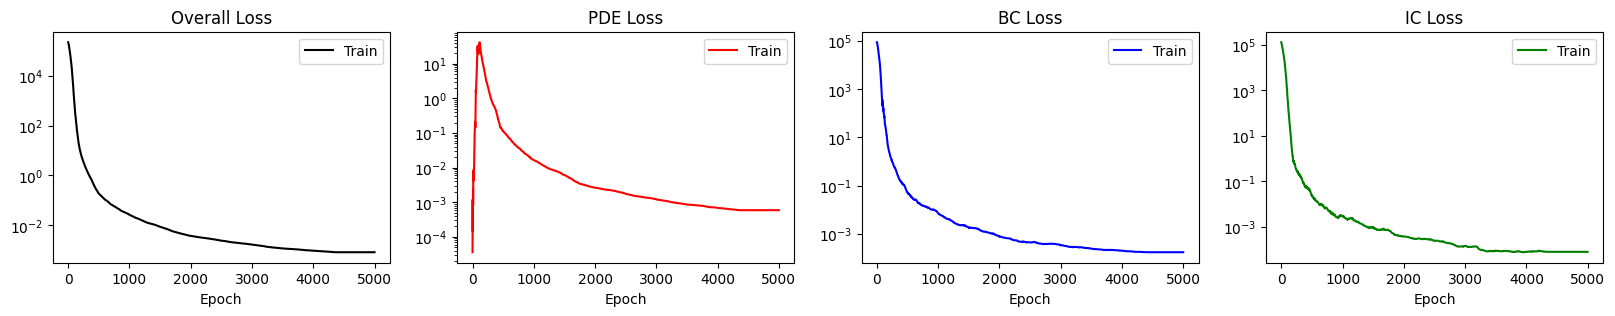

In [ ]:
# Evolution of the loss function
loss_train_list = [loss_train, loss_train_dom, loss_train_bc, loss_train_ic]
colors = ['black', 'red', 'blue', 'green']
titles = ['Overall Loss', 'PDE Loss', 'BC Loss', 'IC Loss']
if isData:
    loss_train_list.append(loss_train_data)
    colors.append('magenta')
    titles.append('Data Loss')

fig, ax = plt.subplots(1, len(loss_train_list), figsize=(20, 3))
for i in range(len(loss_train_list)):
    epochs_train = np.arange(0, len(loss_train_list[i]))
    ax[i].semilogy(epochs_train, loss_train_list[i], color=colors[i], label='Train')
    ax[i].set_xlabel('Epoch')
    ax[i].set_title(titles[i])
    ax[i].legend()
plt.show()

## Prediction for k = 200.

In [ ]:
# Definition of tensors from the testing points for evaluating the trained PINN
k_test = np.full_like(x_test, 200.0)
pt_x = torch.from_numpy(x_test).float()
pt_t = torch.from_numpy(t_test).float()
pt_k = torch.from_numpy(k_test).float()
ms_Tex = T_exact(x_test, t_test, k_test).reshape(ms_x.shape)

In [ ]:
# Predicted solution
X_pred = torch.cat([pt_x, pt_t, pt_k], axis=1).to(device)
Tpred = model(X_pred).data.cpu().numpy()
ms_Tpred = Tpred.reshape(ms_x.shape)

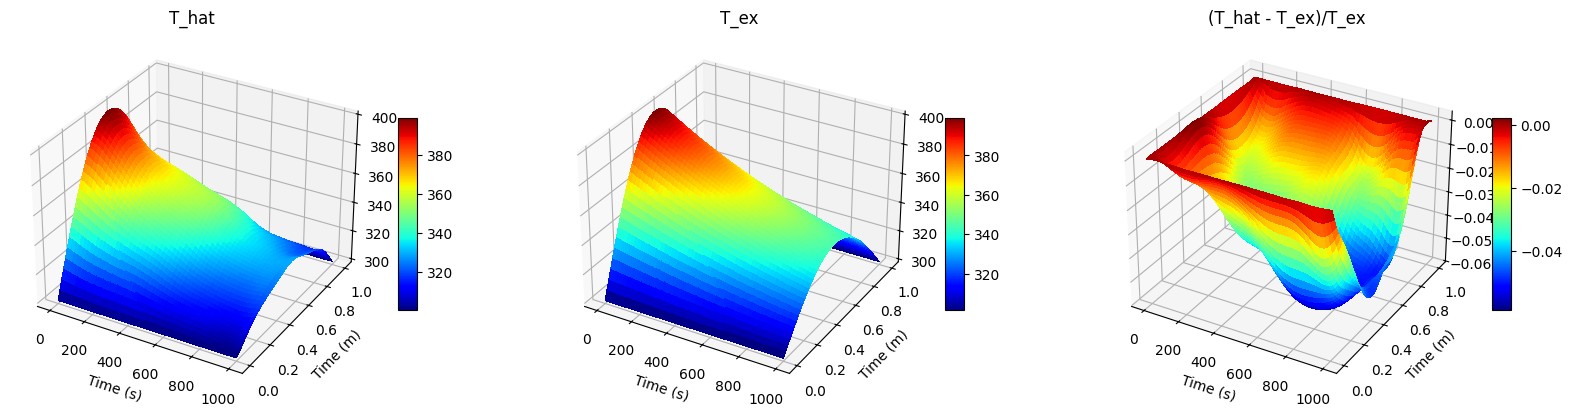

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), subplot_kw=dict(projection='3d'))
ax = axs[0]
surf = ax.plot_surface(ms_t, ms_x, ms_Tpred, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('T_hat')
ax = axs[1]
surf = ax.plot_surface(ms_t, ms_x, ms_Tex, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('T_ex')
ax = axs[2]
surf = ax.plot_surface(ms_t, ms_x, (ms_Tpred-ms_Tex)/ms_Tex, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('(T_hat - T_ex)/T_ex')
plt.show()

## Prediction for k = 250.

In [ ]:
# Definition of tensors from the testing points for evaluating the trained PINN
k_test = np.full_like(x_test, 250.0)
pt_x = torch.from_numpy(x_test).float()
pt_t = torch.from_numpy(t_test).float()
pt_k = torch.from_numpy(k_test).float()
ms_Tex = T_exact(x_test, t_test, k_test).reshape(ms_x.shape)

In [ ]:
# Predicted solution
X_pred = torch.cat([pt_x, pt_t, pt_k], axis=1).to(device)
Tpred = model(X_pred).data.cpu().numpy()
ms_Tpred = Tpred.reshape(ms_x.shape)

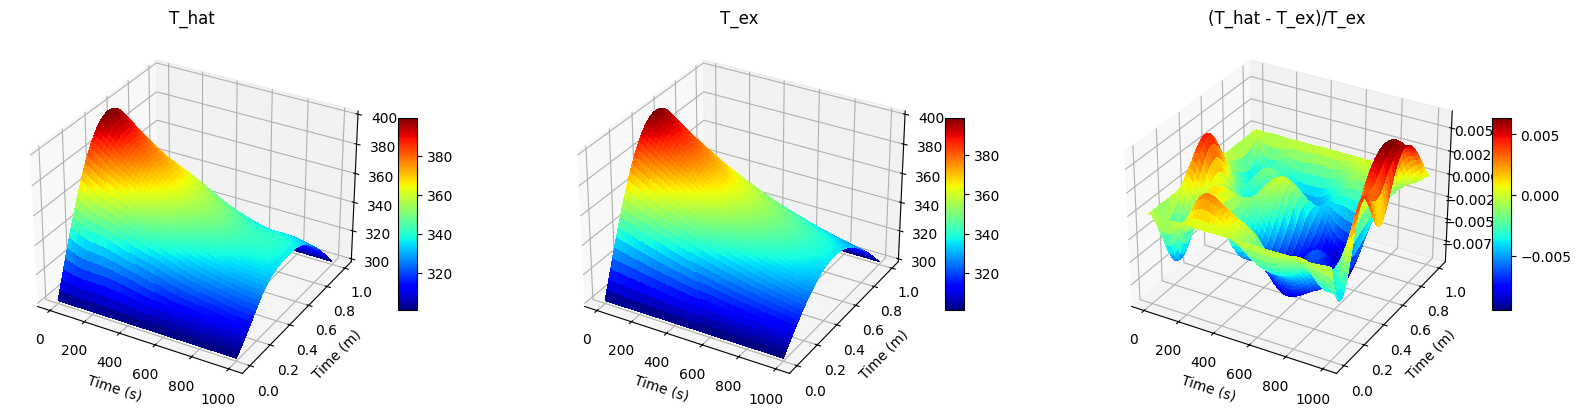

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), subplot_kw=dict(projection='3d'))
ax = axs[0]
surf = ax.plot_surface(ms_t, ms_x, ms_Tpred, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('T_hat')
ax = axs[1]
surf = ax.plot_surface(ms_t, ms_x, ms_Tex, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('T_ex')
ax = axs[2]
surf = ax.plot_surface(ms_t, ms_x, (ms_Tpred-ms_Tex)/ms_Tex, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('(T_hat - T_ex)/T_ex')
plt.show()

## Prediction for k = 300.

In [ ]:
# Definition of tensors from the testing points for evaluating the trained PINN
k_test = np.full_like(x_test, 300.0)
pt_x = torch.from_numpy(x_test).float()
pt_t = torch.from_numpy(t_test).float()
pt_k = torch.from_numpy(k_test).float()
ms_Tex = T_exact(x_test, t_test, k_test).reshape(ms_x.shape)

In [ ]:
# Predicted solution
X_pred = torch.cat([pt_x, pt_t, pt_k], axis=1).to(device)
Tpred = model(X_pred).data.cpu().numpy()
ms_Tpred = Tpred.reshape(ms_x.shape)

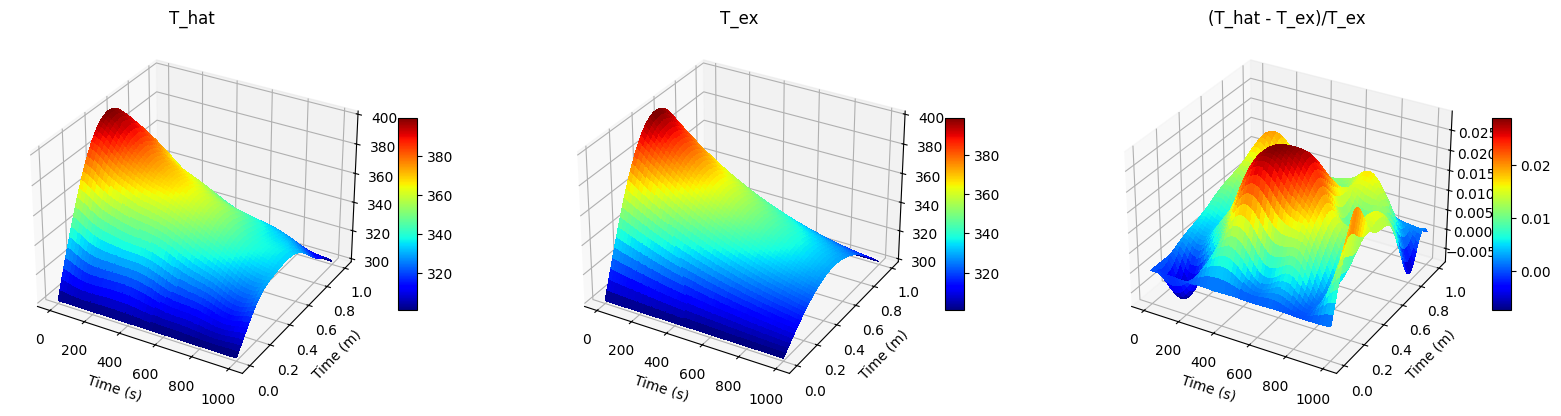

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), subplot_kw=dict(projection='3d'))
ax = axs[0]
surf = ax.plot_surface(ms_t, ms_x, ms_Tpred, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('T_hat')
ax = axs[1]
surf = ax.plot_surface(ms_t, ms_x, ms_Tex, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('T_ex')
ax = axs[2]
surf = ax.plot_surface(ms_t, ms_x, (ms_Tpred-ms_Tex)/ms_Tex, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('(T_hat - T_ex)/T_ex')
plt.show()